# PoC DARL: PhysioNet temporal, POMDP y DQN

Este notebook ejecuta de extremo a extremo el prototipo de _Drift-Aware Reinforcement Learning_ sobre PhysioNet Challenge 2019. La unidad temporal es `ICULOS`: horas transcurridas desde el ingreso de **cada paciente** a UCI. Por tanto, las ventanas representan progresión clínica relativa, no fechas de calendario compartidas.

La causa y severidad reales del drift se conservan solo para evaluación. La política recibe cuatro observaciones consecutivas de siete diagnósticos calibrados (28 valores).


## 1. Configuración reproducible


In [18]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from darl.evaluation import (
    AlwaysDeferPolicy,
    DQNPolicy,
    EmpiricalTablePolicy,
    FixedActionPolicy,
    OraclePolicy,
    RandomPolicy,
    ThresholdPolicy,
    action_distribution,
    collect_transitions,
    evaluate_policies,
    make_live_environment,
    prepare_physionet_poc,
    temporal_drift_summary,
)
from darl.rl import evaluate_policy, split_transition_episodes, train_dqn
from darl.visualization import (
    plot_policy_comparison,
    plot_temporal_drift,
    plot_training_loss,
    save_plot_to_figures,
)

SEED = 42
np.random.seed(SEED)
MAX_PATIENTS = int(os.getenv("DARL_MAX_PATIENTS", "5000"))
MAX_WINDOWS_RAW = os.getenv("DARL_MAX_WINDOWS", None)
MAX_WINDOWS = int(MAX_WINDOWS_RAW) if MAX_WINDOWS_RAW else None
N_BOOTSTRAP = int(os.getenv("DARL_BOOTSTRAPS", "100"))
N_ESTIMATORS = int(os.getenv("DARL_XGB_ESTIMATORS", "200"))
DQN_UPDATES = int(os.getenv("DARL_DQN_UPDATES", "1000"))

ROOT = Path.cwd()
METRICS_DIR = ROOT / "outputs" / "metrics"
MODELS_DIR = ROOT / "outputs" / "models"
METRICS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

config = {
    "seed": SEED,
    "max_patients": MAX_PATIENTS,
    "max_windows": MAX_WINDOWS,
    "bootstraps": N_BOOTSTRAP,
    "xgb_estimators": N_ESTIMATORS,
    "dqn_updates": DQN_UPDATES,
}
config

{'seed': 42,
 'max_patients': 5000,
 'max_windows': None,
 'bootstraps': 100,
 'xgb_estimators': 200,
 'dqn_updates': 1000}

## 2. Carga, validación y separación por paciente


In [22]:
poc = prepare_physionet_poc(
    max_patients=MAX_PATIENTS,
    max_windows=MAX_WINDOWS,
    n_bootstrap=N_BOOTSTRAP,
    n_estimators=N_ESTIMATORS,
    seed=SEED,
)


assert (
    poc.data.groupby("patient_id")["ICULOS"]
    .apply(lambda x: x.is_monotonic_increasing)
    .all()
)
assert not poc.data.duplicated(["patient_id", "ICULOS"]).any()
assert poc.split.train_ids.isdisjoint(poc.split.update_ids)
assert poc.split.train_ids.isdisjoint(poc.split.evaluation_ids)
assert poc.split.update_ids.isdisjoint(poc.split.evaluation_ids)

pd.DataFrame(
    {
        "partición": ["base", "adaptación", "evaluación live"],
        "pacientes": [
            len(poc.split.train_ids),
            len(poc.split.update_ids),
            len(poc.split.evaluation_ids),
        ],
    }
)

,partición,pacientes
0,base,3000
1,adaptación,1000
2,evaluación live,1000


In [26]:
print(poc.split.evaluation_ids)

print(len(poc.data))

print(len(poc.data["patient_id"].unique()))

print(len(poc.split.train_ids))
print(len(poc.split.update_ids))
print(len(poc.split.evaluation_ids))

frozenset({'b_p105055', 'a_p016189', 'b_p106167', 'b_p115179', 'a_p013225', 'b_p111004', 'b_p119134', 'a_p002590', 'b_p117356', 'a_p006268', 'a_p016006', 'a_p010866', 'a_p012118', 'a_p015237', 'b_p108926', 'b_p105824', 'b_p116378', 'a_p008703', 'b_p111065', 'a_p015901', 'b_p109113', 'b_p119627', 'a_p012430', 'a_p007424', 'a_p009112', 'b_p111508', 'b_p111995', 'a_p015890', 'a_p005820', 'a_p017443', 'b_p104748', 'a_p009474', 'b_p117549', 'a_p015582', 'a_p012107', 'b_p103606', 'b_p109045', 'a_p015287', 'b_p116332', 'a_p014368', 'a_p011305', 'b_p107598', 'b_p101070', 'a_p015796', 'b_p108331', 'a_p011772', 'b_p115002', 'b_p107311', 'b_p106673', 'a_p005635', 'a_p004039', 'b_p116055', 'a_p006902', 'b_p106432', 'b_p103875', 'b_p115864', 'b_p117885', 'a_p012407', 'a_p018936', 'a_p018139', 'a_p012285', 'b_p119047', 'b_p113246', 'a_p003585', 'a_p018956', 'b_p107776', 'b_p105213', 'a_p000217', 'a_p006718', 'a_p015298', 'a_p005970', 'b_p112829', 'a_p004363', 'a_p012378', 'b_p119257', 'b_p116267', '

In [ ]:
poc.data["patient_id"].unique()

poc.data[poc.data["patient_id"] == "a_p000020"]

max(poc.data.groupby("patient_id")["ICULOS"].max())

l = [
    max(poc.data[poc.data["patient_id"] == pid]["ICULOS"])
    for pid in poc.data["patient_id"].unique()
]

336
8


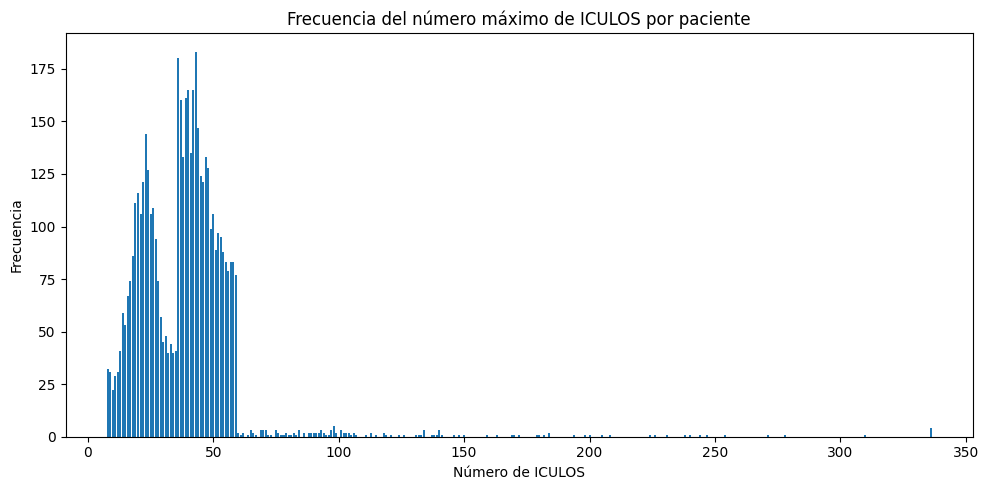

In [5]:
# Máximo ICULOS registrado por cada paciente
icu_los = pd.to_numeric(poc.data["ICULOS"], errors="coerce")
max_iculos = (
    poc.data.assign(_ICULOS=icu_los).groupby("patient_id")["_ICULOS"].max().dropna()
)

l = max_iculos.to_numpy()

print(max(l))
print(min(l))

# Frecuencia de cada número de ICULOS
frecuencias = pd.Series(l).value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(frecuencias.index, frecuencias.values)

plt.xlabel("Número de ICULOS")
plt.ylabel("Frecuencia")
plt.title("Frecuencia del número máximo de ICULOS por paciente")
plt.tight_layout()
plt.show()

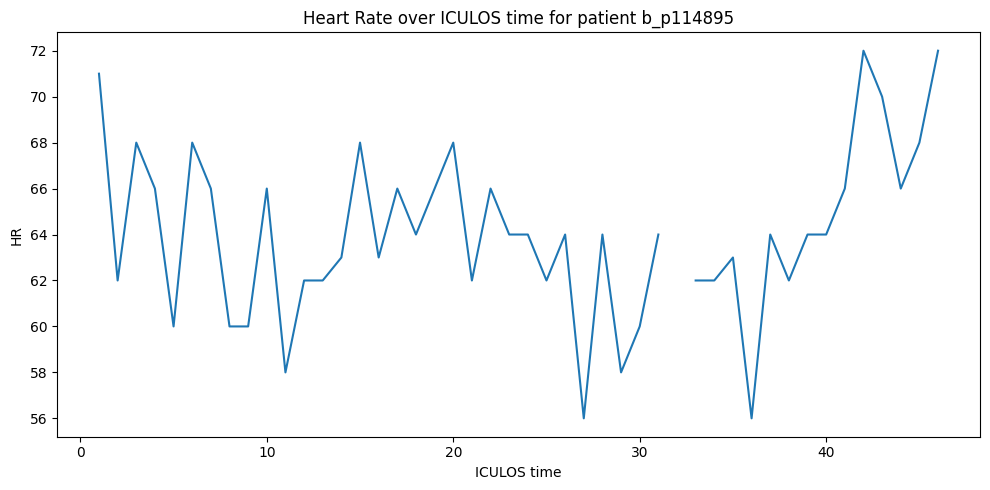

In [31]:
sample = poc.data[poc.data["patient_id"] == "b_p114895"]

l = pd.to_numeric(sample["HR"], errors="coerce").to_numpy()

plt.figure(figsize=(10, 5))
plt.plot(range(len(l)), l)

plt.xlabel("ICULOS time")
plt.ylabel("HR")
plt.title("Heart Rate over ICULOS time for patient b_p114895")
plt.tight_layout()
plt.show()

In [42]:
hr_features = poc.data.groupby("patient_id")["HR"].agg(
    hr_mean="mean",
    hr_std="std",
    hr_min="min",
    hr_max="max",
    hr_last="last",
    hr_missing=lambda x: round(x.isna().mean() * 100, 2),
)

hr_features.head()

,hr_mean,hr_std,hr_min,hr_max,hr_last,hr_missing
patient_id,,,,,,
a_p000020,61.500000,4.527693,54.0,69.0,63.0,5.26
a_p000021,96.909091,9.215572,77.0,118.0,77.0,3.51
a_p000041,81.040000,9.753119,61.0,101.0,85.0,26.47
a_p000048,81.312500,8.419966,66.0,95.0,88.0,0.00
a_p000056,89.000000,4.140393,84.0,94.0,93.0,11.11


## 3. Cohortes temporales y drift natural

Las horas 1–6 forman la referencia. Desde la hora 7 hasta la 60 se crean cohortes de tres horas y se conserva la última observación disponible de cada paciente en cada cohorte.


,window_start,window_end,n_samples,prevalence,mean_psi
0,7,9,996,0.025100,0.089239
1,10,12,982,0.021385,0.142418
2,13,15,966,0.014493,0.253781
3,16,18,936,0.012821,0.260081
4,19,21,884,0.006787,0.907590
5,22,24,818,0.003667,0.310781
6,25,27,751,0.005326,1.322295
7,28,30,687,0.002911,0.743610
8,31,33,653,0.004594,0.540763
9,34,36,627,0.006380,0.600407


Figura exportada y guardada en: c:\Users\jeffr\GitHub\tesis-darl\outputs\figures\physionet_temporal_drift.png


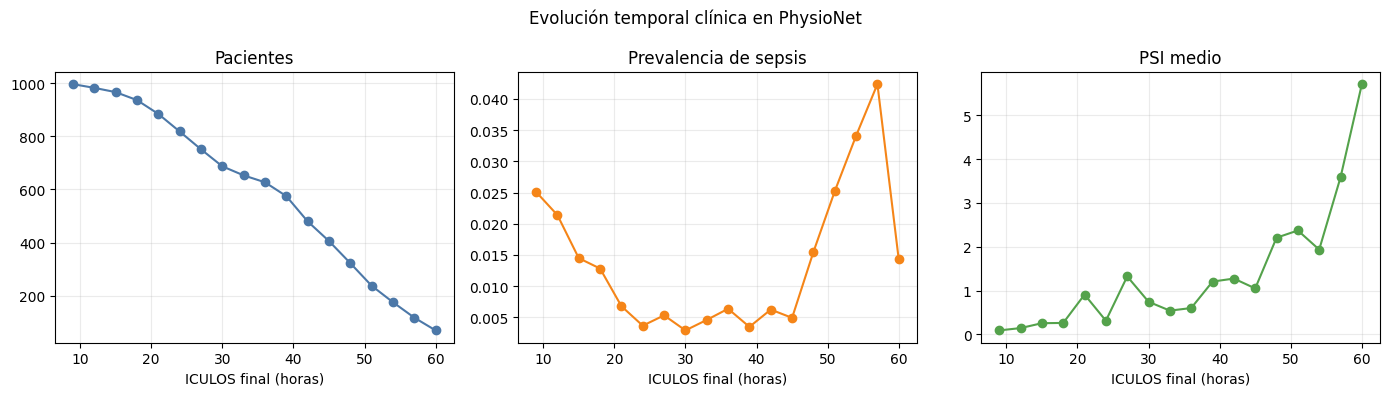

In [23]:
window_summary = temporal_drift_summary(poc)
display(window_summary)

temporal_figure = plot_temporal_drift(window_summary)
save_plot_to_figures(temporal_figure, "physionet_temporal_drift.png")
plt.show()

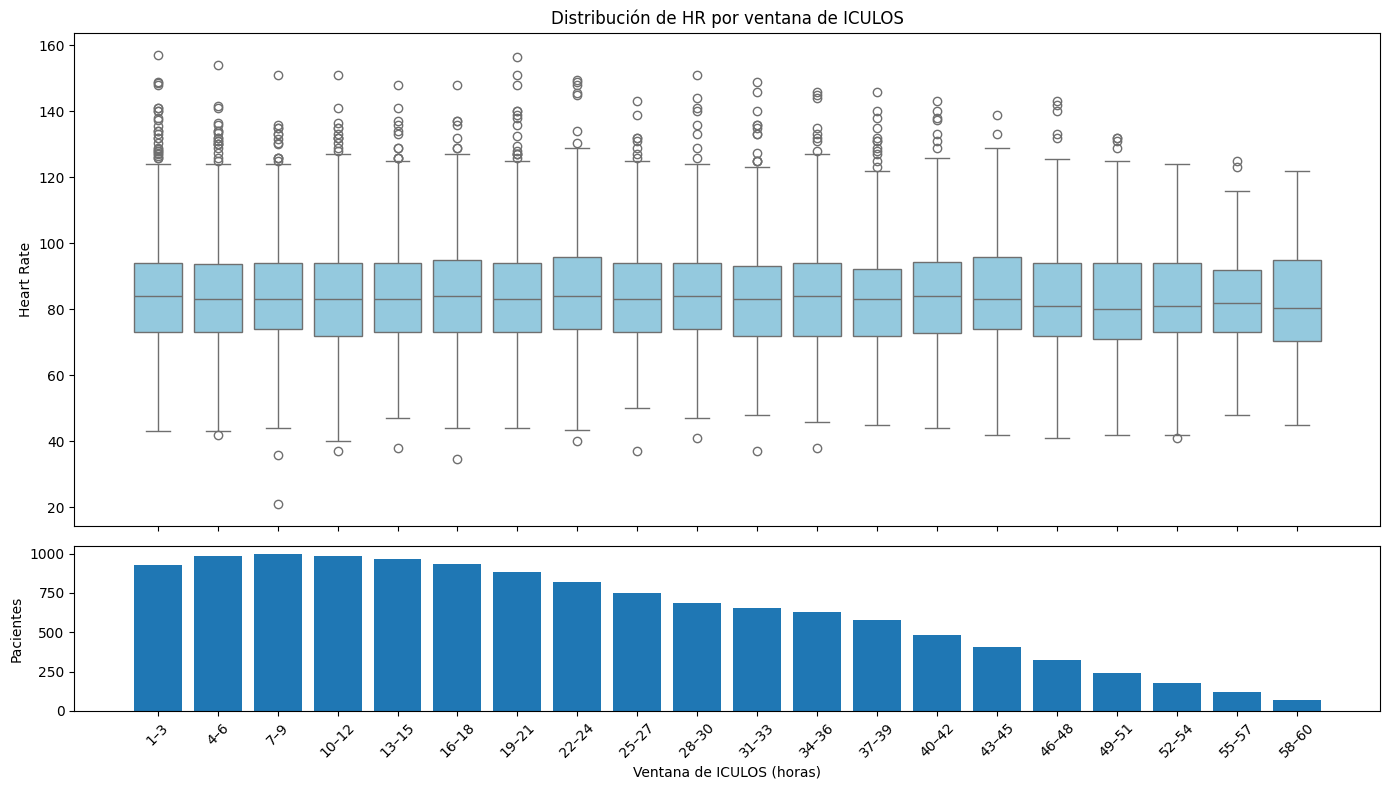

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = poc.data[poc.data["patient_id"].isin(poc.split.evaluation_ids)].copy()

df = df[df["ICULOS"].between(1, 60)]

df["window_start"] = 1 + ((df["ICULOS"] - 1) // 3) * 3
df["window_end"] = df["window_start"] + 2

df["window"] = (
    df["window_start"].astype(int).astype(str)
    + "–"
    + df["window_end"].astype(int).astype(str)
)

# Última observación de cada paciente en cada ventana
window_data = (
    df.sort_values(["patient_id", "ICULOS"])
    .groupby(["patient_id", "window_start"], as_index=False)
    .tail(1)
)

# Mantener el orden temporal de las ventanas
window_order = (
    window_data[["window_start", "window"]]
    .drop_duplicates()
    .sort_values("window_start")["window"]
)

fig, axes = plt.subplots(
    2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)

# Distribución de HR
sns.boxplot(
    data=window_data,
    x="window",
    y="HR",
    order=window_order,
    ax=axes[0],
    color="skyblue",
)

axes[0].set_title("Distribución de HR por ventana de ICULOS")
axes[0].set_ylabel("Heart Rate")
axes[0].set_xlabel("")

# Cantidad de pacientes disponibles
patient_counts = (
    window_data.groupby("window")["patient_id"].nunique().reindex(window_order)
)

axes[1].bar(patient_counts.index, patient_counts.values)
axes[1].set_ylabel("Pacientes")
axes[1].set_xlabel("Ventana de ICULOS (horas)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 4. Pipeline base XGBoost de dos etapas


In [25]:
pipeline_summary = pd.DataFrame(
    [
        {
            "auc_base": poc.auc_base,
            "stage1_version": poc.pipeline_state.stage1_version,
            "stage2_version": poc.pipeline_state.stage2_version,
            "features_predictivas": len(poc.feature_columns),
            "vitales_stage1": len(poc.vitals),
        }
    ]
)
pipeline_summary

,auc_base,stage1_version,stage2_version,features_predictivas,vitales_stage1
0,0.683121,0,0,19,7


## 5. Monitor calibrado y observación POMDP

PSI, KS, C2ST y degradación predictiva se calibran por _bootstrap_ bajo H0. `true_drift_type`, escenario y severidad inyectada nunca forman parte del vector observable.


In [26]:
calibration = poc.monitor.calibration_
calibration_table = pd.DataFrame([calibration.thresholds])
assert (calibration_table.to_numpy() > 0).all()

natural_env = make_live_environment(poc)
observation, _ = natural_env.reset(seed=SEED)
assert observation.shape == (28,)
assert "true_drift_type" not in poc.monitor.observation_schema
display(calibration_table)
pd.Series(observation, name="observación inicial (28)")

,psi,ks,c2st,auc_loss,logloss_gain
0,0.322897,0.096226,0.539783,0.147718,0.038607


0     0.000000
1     0.000000
2     0.000000
3     0.000000
4     0.000000
5     0.000000
6     0.000000
7     0.000000
8     0.000000
9     0.000000
10    0.000000
11    0.000000
12    0.000000
13    0.000000
14    0.000000
15    0.000000
16    0.000000
17    0.000000
18    0.000000
19    0.000000
20    0.000000
21    0.049995
22    0.149005
23    0.791589
24    0.891089
25    0.791589
26   -0.143553
27    0.000000
Name: observación inicial (28), dtype: float32

## 6. Drift controlado y transiciones contrafactuales

Se generan episodios con severidades progresivas 0.25, 0.60 y 0.90. En cada estado se clona el pipeline live y se prueban A1–A4. El concept drift usa `label_flip_control`; `boundary_shift` y `feature_swap` permanecen disponibles en la API.


In [27]:
episodes = [
    collect_transitions(
        poc,
        scenario="control",
        true_drift_type="both",
        severity=severity,
        seed=SEED + index,
    )
    for index, severity in enumerate((0.25, 0.60, 0.90))
]
transitions = pd.concat(episodes, ignore_index=True)
train_transitions, validation_transitions = split_transition_episodes(
    transitions, validation_fraction=1 / 3, seed=SEED
)
assert set(train_transitions["episode_id"]).isdisjoint(
    validation_transitions["episode_id"]
)
assert transitions.groupby(["episode_id", "step"])["action"].nunique().eq(4).all()
transitions.to_pickle(METRICS_DIR / "physionet_empirical_transitions.pkl")
transitions[
    [
        "episode_id",
        "step",
        "action_requested",
        "action_executed",
        "reward",
        "auc_before",
        "auc_after",
        "normalized_cost",
        "window_start",
        "window_end",
    ]
].head(12)

c:\Users\jeffr\GitHub\tesis-darl\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\jeffr\GitHub\tesis-darl\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\jeffr\GitHub\tesis-darl\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\jeffr\GitHub\tesis-darl\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\jeffr\GitHub\tesis-darl\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: ks

,episode_id,step,action_requested,action_executed,reward,auc_before,auc_after,normalized_cost,window_start,window_end
0,control-both-0.25-42,0,A1,A1,-1.383832e-05,0.513711,0.513711,0.000055,7,9
1,control-both-0.25-42,0,A2,A4,1.121527e-01,0.513711,0.575063,1.000000,7,9
2,control-both-0.25-42,0,A3,A3,9.813370e-02,0.513711,0.569572,0.926413,7,9
3,control-both-0.25-42,0,A4,A4,1.121527e-01,0.513711,0.575063,1.000000,7,9
4,control-both-0.25-42,1,A1,A1,-6.881414e-07,0.515386,0.515386,0.000003,10,12
5,control-both-0.25-42,1,A2,A4,-8.334394e-02,0.515386,0.543340,1.000000,10,12
6,control-both-0.25-42,1,A3,A3,-3.500513e-02,0.515386,0.547833,0.913781,10,12
7,control-both-0.25-42,1,A4,A4,-8.334394e-02,0.515386,0.543340,1.000000,10,12
8,control-both-0.25-42,2,A1,A1,-8.277260e-07,0.559511,0.559511,0.000003,13,15
9,control-both-0.25-42,2,A2,A2,-3.008242e-01,0.559511,0.553229,1.000000,13,15


## 7. Entrenamiento offline del DQN propio


Figura exportada y guardada en: c:\Users\jeffr\GitHub\tesis-darl\outputs\figures\physionet_dqn_loss.png


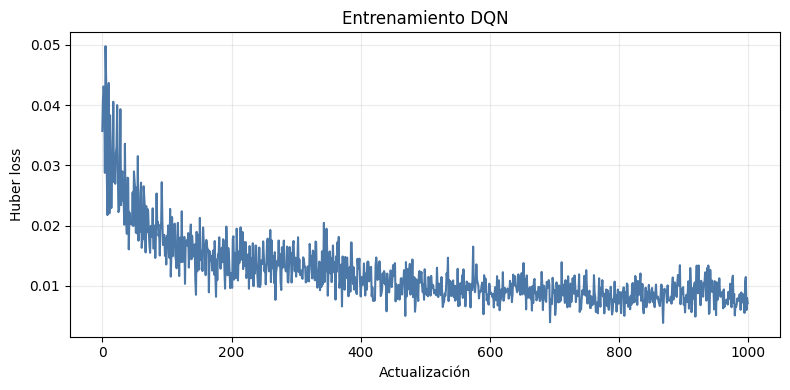

,update,loss
995,995,0.010671
996,996,0.011482
997,997,0.006009
998,998,0.007998
999,999,0.007128


In [28]:
agent, training_history = train_dqn(
    train_transitions,
    updates=DQN_UPDATES,
    batch_size=64,
    seed=SEED,
)

agent.save(MODELS_DIR / "physionet_darl_dqn.pt")
training_history.to_csv(METRICS_DIR / "physionet_dqn_training.csv", index=False)
loss_figure = plot_training_loss(training_history)
save_plot_to_figures(loss_figure, "physionet_dqn_loss.png")
plt.show()
training_history.tail()

## 8. Evaluación comparable de políticas


,policy,mean_reward,mean_episode_reward,mean_auc_before,mean_auc_after,mean_recovery_ratio,total_time_s,peak_ram_mb,optimal_action_rate,mean_regret,full_retrainings_avoided,reward_ci_low,reward_ci_high,seed
8,Oracle,1.766981e-02,0.318057,0.491644,0.504897,0.056702,1.076081,2.821475,1.000000,0.000000,0.944444,0.318057,0.318057,42
2,Always defer,-5.913407e-07,-0.000011,0.491644,0.491644,0.000000,0.000038,0.000000,0.833333,0.017670,1.000000,-0.000011,-0.000011,42
0,DQN,-2.447002e-02,-0.440460,0.491644,0.492346,0.003308,0.902644,2.857981,0.722222,0.042140,0.888889,-0.440460,-0.440460,42
7,Empirical,-4.649048e-02,-0.836829,0.491644,0.493529,0.007431,1.945395,1.235925,0.611111,0.064160,0.888889,-0.836829,-0.836829,42
1,Random,-1.496006e-01,-2.692811,0.491644,0.496766,0.023924,6.864757,2.995957,0.333333,0.167270,0.722222,-2.692811,-2.692811,42
6,Threshold,-2.133642e-01,-3.840555,0.491644,0.501233,0.036636,13.852269,1.282029,0.055556,0.231034,0.000000,-3.840555,-3.840555,42
5,Fixed A4,-2.133642e-01,-3.840555,0.491644,0.501233,0.036636,13.852269,1.282029,0.055556,0.231034,0.000000,-3.840555,-3.840555,42
4,Fixed A3,-2.180846e-01,-3.925522,0.491644,0.499513,0.015641,12.968259,1.235925,0.111111,0.235754,1.000000,-3.925522,-3.925522,42
3,Fixed A2,-2.307771e-01,-4.153987,0.491644,0.495968,0.019223,5.936843,3.016876,0.055556,0.248447,0.444444,-4.153987,-4.153987,42


action_requested,policy,A1,A2,A3,A4
0,Always defer,1.000000,0.000000,0.000000,0.000000
1,DQN,0.888889,0.111111,0.000000,0.000000
2,Empirical,0.777778,0.000000,0.111111,0.111111
3,Fixed A2,0.000000,1.000000,0.000000,0.000000
4,Fixed A3,0.000000,0.000000,1.000000,0.000000
5,Fixed A4,0.000000,0.000000,0.000000,1.000000
6,Oracle,0.833333,0.055556,0.111111,0.000000
7,Random,0.277778,0.111111,0.333333,0.277778
8,Threshold,0.000000,0.000000,0.000000,1.000000


Figura exportada y guardada en: c:\Users\jeffr\GitHub\tesis-darl\outputs\figures\physionet_policy_comparison.png


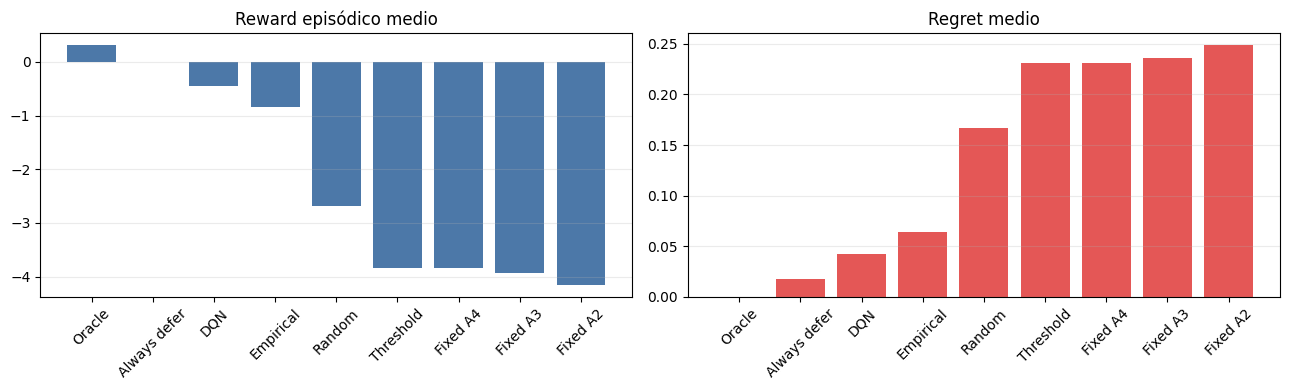

In [29]:
empirical_policy = EmpiricalTablePolicy().fit(train_transitions)
policies = {
    "DQN": DQNPolicy(agent),
    "Random": RandomPolicy(SEED),
    "Always defer": AlwaysDeferPolicy(),
    "Fixed A2": FixedActionPolicy(1),
    "Fixed A3": FixedActionPolicy(2),
    "Fixed A4": FixedActionPolicy(3),
    "Threshold": ThresholdPolicy(0.5),
    "Empirical": empirical_policy,
    "Oracle": OraclePolicy(),
}
policy_summary, policy_steps = evaluate_policies(
    validation_transitions, policies, seed=SEED
)
policy_summary.to_csv(METRICS_DIR / "physionet_policy_summary.csv", index=False)
action_distribution(policy_steps).to_csv(
    METRICS_DIR / "physionet_action_distribution.csv", index=False
)
display(policy_summary.sort_values("mean_episode_reward", ascending=False))
display(action_distribution(policy_steps))
comparison_figure = plot_policy_comparison(policy_summary)
save_plot_to_figures(comparison_figure, "physionet_policy_comparison.png")
plt.show()

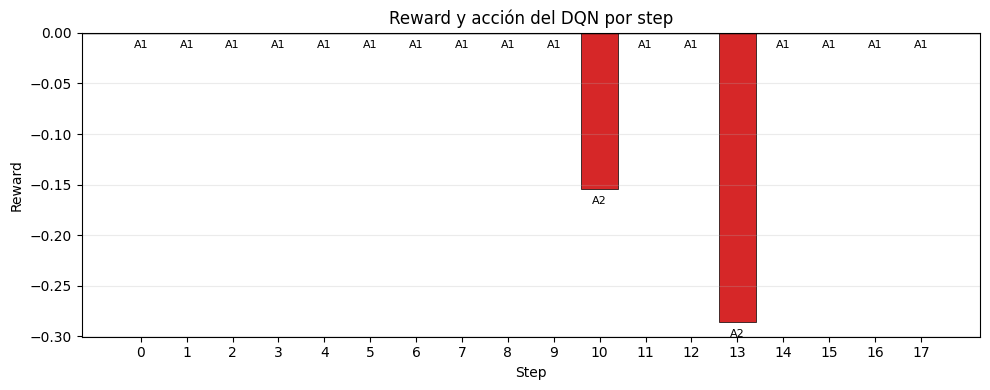

In [30]:
dqn_steps = policy_steps.loc[policy_steps["policy"] == "DQN"].sort_values("step").copy()

colors = [
    "#2ca02c" if reward > 0 else "#d62728" if reward < -1e-4 else "#bdbdbd"
    for reward in dqn_steps["reward"]
]

fig, ax = plt.subplots(figsize=(10, 4))

bars = ax.bar(
    dqn_steps["step"],
    dqn_steps["reward"],
    color=colors,
    edgecolor="black",
    linewidth=0.5,
)

ax.axhline(0, color="black", linewidth=1)

# Mostrar la acción elegida sobre cada barra
for bar, action, reward in zip(
    bars,
    dqn_steps["action_requested"],
    dqn_steps["reward"],
):
    ax.annotate(
        action,
        xy=(bar.get_x() + bar.get_width() / 2, reward),
        xytext=(0, 5 if reward >= 0 else -5),
        textcoords="offset points",
        ha="center",
        va="bottom" if reward >= 0 else "top",
        fontsize=8,
    )

ax.set_title("Reward y acción del DQN por step")
ax.set_xlabel("Step")
ax.set_ylabel("Reward")
ax.set_xticks(dqn_steps["step"])
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## 9. Validación final live (`epsilon=0`)

Esta ejecución no consulta recompensas contrafactuales para decidir. El DQN observa el historial diagnóstico, actúa de forma determinista y modifica el pipeline persistente antes de avanzar a la siguiente cohorte.


In [9]:
live_env = make_live_environment(
    poc, scenario="control", true_drift_type="both", severity=0.90, seed=SEED + 100
)
live_results = evaluate_policy(agent, live_env, n_episodes=1)
live_results.to_csv(METRICS_DIR / "physionet_dqn_live.csv", index=False)
live_results

,episode,step,action,reward,action_name,action_requested,action_executed,fallback_reason,auc_base,auc_before,...,recovery_ratio,time_s,peak_ram_mb,normalized_cost,window_start,window_end,scenario,true_drift_type,severity,seed
0,0,0,0,-0.000002,defer,A1,A1,None,0.434783,0.447368,...,0.0,0.000002,0.0,0.000009,7,9,control,both,0.45,142
1,0,1,0,-0.000002,defer,A1,A1,None,0.434783,0.562500,...,0.0,0.000002,0.0,0.000007,10,12,control,both,0.90,142


## 10. Resultado de aceptación y limitaciones


In [ ]:
returns = policy_summary.set_index("policy")["mean_episode_reward"]
dqn_beats_random = bool(returns["DQN"] > returns["Random"])
acceptance = pd.DataFrame(
    [
        {
            "dqn_mean_return": returns["DQN"],
            "random_mean_return": returns["Random"],
            "dqn_supera_random": dqn_beats_random,
            "poc_aceptada": dqn_beats_random,
        }
    ]
)
acceptance.to_csv(METRICS_DIR / "physionet_acceptance.csv", index=False)
acceptance

,dqn_mean_return,random_mean_return,dqn_supera_random,poc_aceptada
0,-0.000004,-0.250002,True,True


El resultado se reporta sin alterar si DQN no supera a Random. Limitaciones: `ICULOS` no es calendario global; el concept drift principal usa flips controlados de etiquetas; la tabla contrafactual aproxima la dinámica y la demo limita pacientes para mantener costo manejable. Próximos pasos: drift conceptual fisiológicamente plausible, más episodios independientes, búsqueda de hiperparámetros y corrida completa con los 40 336 pacientes.
